# 04 · Animated maps, small multiples, and lag

**Decision question.** Which spatial and temporal patterns can we see, and how do we avoid reading causality into a moving map?

**Time:** 30–45 minutes. **Prerequisites:** basic Python arrays and tables. Run cells from top to bottom.
The shared `rewiring.py` module must stay beside the notebooks. Initial package downloads require internet;
the core calculations use reproducible synthetic data. No health-service credentials are needed.

**Data contract:** the fictional grid is geographically anchored near Gaborone for teaching map coordinates.
Its people, facilities, climate, events, and model parameters are invented. It is **not a map of actual
Gaborone disease, vulnerability, buildings, or care access**. Satellite catalog metadata, when used, is labeled separately.

[Book](https://jltobias.github.io/JupyterLite-Rewiring-Global-Health/) · [Interactive demo gallery](https://jltobias.github.io/JupyterLite-Rewiring-Global-Health/demos/) · [Data and credits](https://github.com/jltobias/JupyterLite-Rewiring-Global-Health/blob/main/DATA_SOURCES.md)

In [1]:
import sys
if sys.platform == 'emscripten':
    import micropip
    await micropip.install(['numpy', 'pandas', 'matplotlib'])
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML, IFrame
from rewiring import (city, long_table, map_image, map_matrix, geojson,
                      leaflet, save_export, simulate_twin, teaching_review, HATS, SITE, LABEL, EXTENT)
plt.rcParams.update({'figure.dpi': 105, 'axes.spines.top': False, 'axes.spines.right': False})
cells, cube = city()
panel = long_table(cells, cube)
print(LABEL)
print('Python', sys.version.split()[0], '| cells:', len(cells), '| monthly observations:', len(panel))

SYNTHETIC teaching data · not observations or a forecast
Python 3.13.14 | cells: 64 | monthly observations: 1536


## Animation and small multiples answer different questions

Animation directs attention to change; a map matrix supports comparisons without remembering previous frames.
Both need consistent color limits, temporal resolution, and missing-data rules. Our monthly series has a
known generated seasonal component. Counts also depend on the invented population distribution.

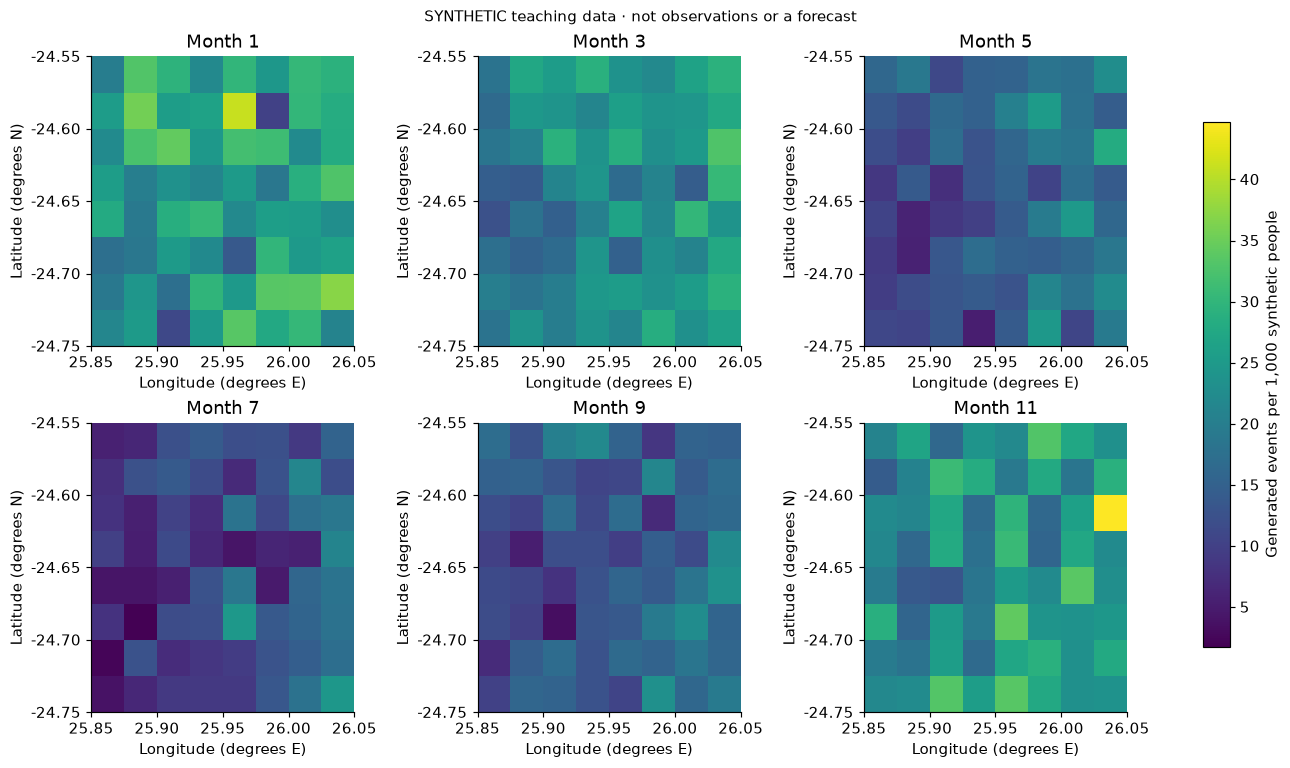

In [2]:
chosen=[0,2,4,6,8,10]
map_matrix(cube['rate_per_1000'][chosen],[f'Month {t+1}' for t in chosen],
           'Generated events per 1,000 synthetic people',columns=3)
plt.show()

## An animated choropleth with a fixed scale

Use play, pause, and frame controls. Pause before comparing distant times; the static matrix is an equal
part of the analysis. The animation below is generated locally and makes no calls to a map service.

In [3]:
from matplotlib.animation import FuncAnimation
series=cube['rate_per_1000']
fig,ax=plt.subplots(figsize=(6,4.8),layout='constrained')
im=map_image(ax,series[0],'Synthetic month 1',series.min(),series.max())
fig.colorbar(im,ax=ax,label='Events per 1,000 synthetic people')
def update(frame):
    im.set_data(series[frame]); ax.set_title(f'Synthetic month {frame+1} / {len(series)}')
    return (im,)
animation=FuncAnimation(fig,update,frames=len(series),interval=250,blit=False)
plt.close(fig)
display(HTML(animation.to_jshtml(default_mode='once')))

## Use denominators and align the time axis

The citywide rate is total events divided by total population. It is not an unweighted average of cell rates.
A heatmap puts every cell on the same time axis; a Hovmöller-style diagram averages over longitude to
compare north–south patterns through time. Averaging can hide local differences, so retain the map matrix.

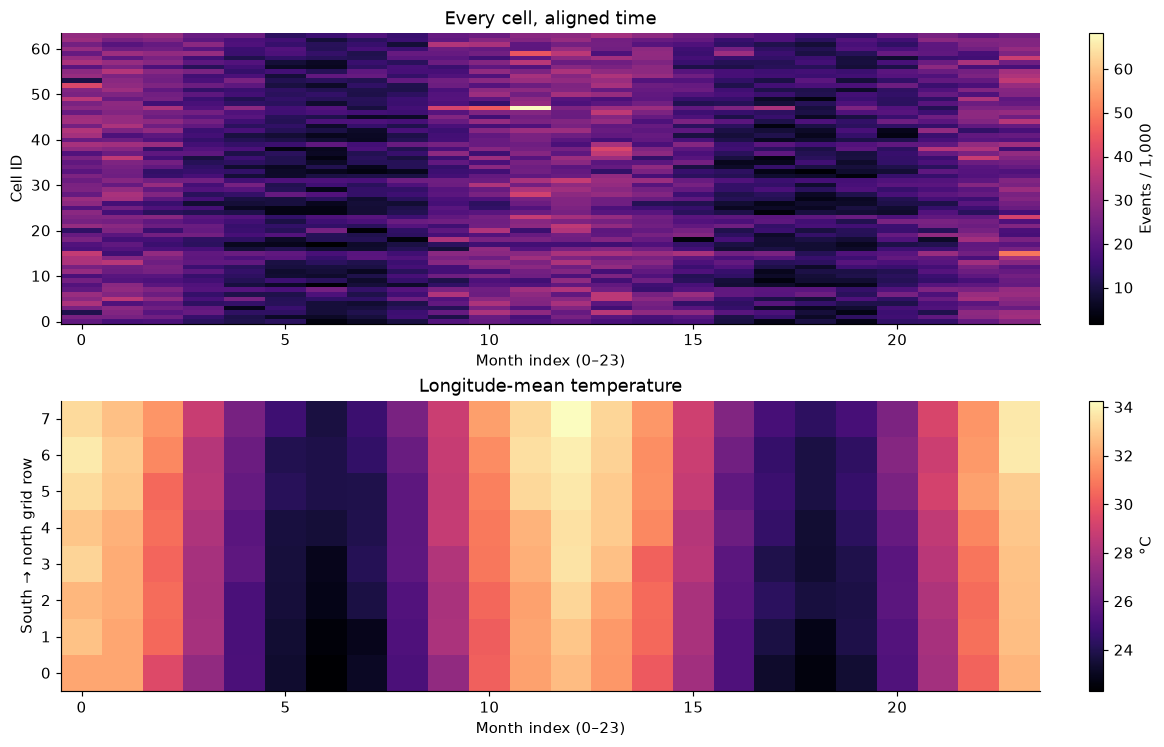

In [4]:
overall=1000*series.reshape(24,-1).dot(cells.population.to_numpy())/cells.population.sum()/1000
fig,axes=plt.subplots(2,1,figsize=(11,7),layout='constrained')
im=axes[0].imshow(series.reshape(24,-1).T,aspect='auto',origin='lower',cmap='magma')
axes[0].set(xlabel='Month index (0–23)',ylabel='Cell ID',title='Every cell, aligned time')
fig.colorbar(im,ax=axes[0],label='Events / 1,000')
im=axes[1].imshow(cube['heat_c'].mean(axis=2).T,aspect='auto',origin='lower',cmap='magma')
axes[1].set(xlabel='Month index (0–23)',ylabel='South → north grid row',title='Longitude-mean temperature')
fig.colorbar(im,ax=axes[1],label='°C'); plt.show()

## A lag demonstration without circular wraparound

We deliberately generate events associated with rainfall three weeks earlier. Missing early lags remain
missing, rather than borrowing rainfall from the end of the year. A correlation peak in this constructed
example verifies the mechanism we wrote; it is not evidence for a biological lag in real populations.

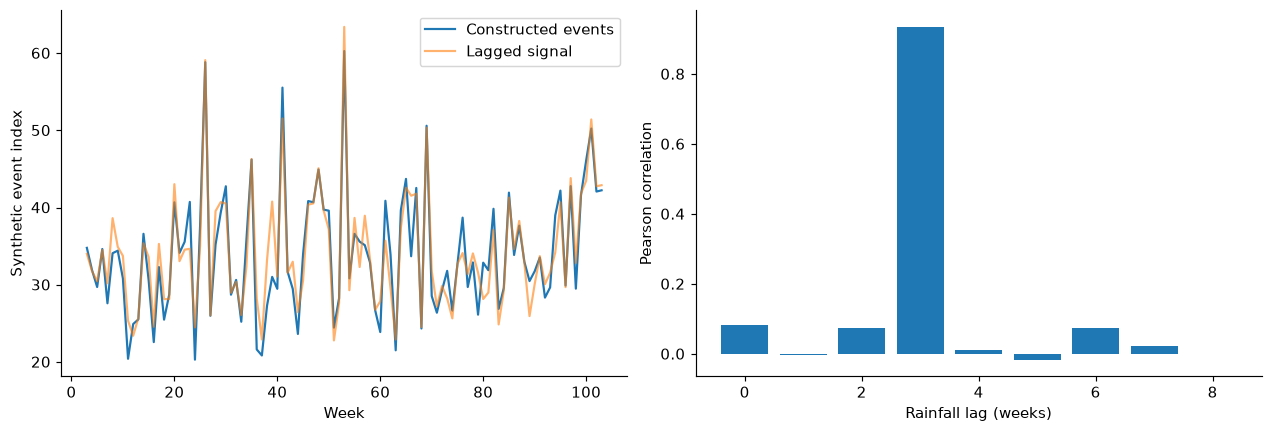

In [5]:
rng=np.random.default_rng(7)
rain=pd.Series(rng.gamma(3,15,104),name='rain_mm')
lagged=rain.shift(3)
events=20+.35*lagged+rng.normal(0,3,104)
correlations=pd.Series({lag:rain.shift(lag).corr(events) for lag in range(9)})
fig,axes=plt.subplots(1,2,figsize=(12,4),layout='constrained')
axes[0].plot(events,label='Constructed events'); axes[0].plot(.35*lagged+20,label='Lagged signal',alpha=.6)
axes[0].set(xlabel='Week',ylabel='Synthetic event index'); axes[0].legend()
axes[1].bar(correlations.index,correlations); axes[1].set(xlabel='Rainfall lag (weeks)',ylabel='Pearson correlation')
plt.show()
assert events.iloc[:3].isna().all()

## Investigate, interpret, and discuss

1. Compare counts with rates. Which places change rank and why?
2. Introduce missing observations into months 5–7. Show missingness rather than replacing it with zero.
3. Change the generated lag to five weeks. Discuss confounding and multiple testing in real lag searches.

**Before sharing:** state the decision, data status, units, denominator, scale, uncertainty, and who can contest the result.
Record what would change your conclusion. Export only information that the intended audience needs.

## Sources and attribution

- [Matplotlib animation](https://matplotlib.org/stable/api/animation_api.html).
- [Related Zarr teaching atlas](https://github.com/jltobias/JupyterLite-zarr-sql-views).
- All animation frames and time series are original synthetic examples. No clinical or climate inference is intended.

Original lesson code: MIT. Original narrative, synthetic data, and generated figures: CC BY 4.0.
Third-party data, videos, services, and software retain their own terms.
[Full references](https://github.com/jltobias/JupyterLite-Rewiring-Global-Health/blob/main/REFERENCES.md) · [Third-party notices](https://github.com/jltobias/JupyterLite-Rewiring-Global-Health/blob/main/THIRD_PARTY_NOTICES.md).